# Standard Transformer Baseline


given the past 168 hours of POWER + 12 NWP variables, forecast the next 24
hours of POWER. 

In [1]:
import sys, math, random
sys.path.insert(0, "/Users/lin_/Solar_Prediction")   # make `src` importable
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)

torch 2.7.1 | device: mps


## 1. Data

Built with `GEFComTask15().load().deaccumulate()` so the four accumulated NWP
fields (daily-cumulative radiation/precipitation) are replaced by their true
hourly increments (`*_dea`), which is the physically meaningful driver of solar
power. The leakage-safe `time_split` from `src/helper` splits each zone 70/15/15
by time; windows stay within a segment. Input features are standardized with
train statistics; the POWER target stays in [0, 1].

In [2]:
from src.helper.data_preprocessing import GEFComTask15, NWP_VARS, ACCUM_VARS
from src.helper.backtest import time_split
from src.vanilla_transformer import Standardizer

L, H = 168, 24                          # lookback, horizon
TARGET = "POWER"

# Use the de-accumulated NWP fields: the four accumulated variables (daily-cumulative
# radiation/precipitation) are replaced by their true hourly increments (`*_dea`).
NON_ACCUM = [v for v in NWP_VARS if v not in ACCUM_VARS]
DEA_VARS  = [f"{v}_dea" for v in ACCUM_VARS]
FEATURES  = [TARGET] + NON_ACCUM + DEA_VARS    # 13 features (POWER first)

ds = GEFComTask15().load().deaccumulate()      # deaccumulate() adds the `*_dea` columns
df = ds.combined.copy()
df[TARGET] = df[TARGET].clip(0, 1)

# per-zone time split -> contiguous frames (windows never cross a zone/split boundary)
frames = {"train": [], "val": [], "test": []}
for z, g in df.groupby("ZONE"):
    tr, va, te = time_split(g.sort_values("ts"), (0.70, 0.15, 0.15))
    frames["train"].append(tr)
    frames["val"].append(va)
    frames["test"].append(te)

# standardize inputs with train statistics only (target POWER stays raw in [0, 1])
std = Standardizer.fit_frames(frames["train"], FEATURES)
print("features:", FEATURES)
print({k: sum(len(g) for g in v) for k, v in frames.items()})

features: ['POWER', 'VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166', 'VAR167', 'VAR169_dea', 'VAR175_dea', 'VAR178_dea', 'VAR228_dea']
{'train': 41376, 'val': 8868, 'test': 8868}


## 2. Sliding-window dataset

`WindowDataset.from_frames` (in `src/vanilla_transformer`) maps each standardized
input window `[L, n_features]` to the POWER target `[H]`. Each split builds
windows only inside its own frames, so the first `L` points of every frame are
not predicted and no window crosses a split. `make_dataloaders` shuffles only
the train loader; val/test stay ordered with `drop_last=False` so every window
is evaluated.

In [3]:
from src.vanilla_transformer import WindowDataset, make_dataloaders

datasets = {
    split: WindowDataset.from_frames(frames[split], FEATURES, TARGET, L, H, std)
    for split in ("train", "val", "test")
}
loaders = make_dataloaders(datasets, batch_size=64, seed=SEED, device=device)

train_ds, val_ds, test_ds = datasets["train"], datasets["val"], datasets["test"]
train_dl, val_dl, test_dl = loaders["train"], loaders["val"], loaders["test"]
print(f"windows -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")
print("n_features:", train_ds.n_features, "| horizon:", train_ds.horizon)

windows -> train 40803 | val 8295 | test 8295
n_features: 13 | horizon: 24


## 3. Model

A standard encoder-only Transformer: linear input projection -> sinusoidal
positional encoding -> `nn.TransformerEncoder` -> mean-pool over time -> linear head
to the 24h horizon.

In [4]:
from src.vanilla_transformer import TransformerForecaster

model = TransformerForecaster(
    n_features=train_ds.n_features,
    context_length=L,
    horizon=H,
    d_model=64, nhead=8, num_layers=2, dim_ff=128, dropout=0.1,
).to(device)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

TransformerForecaster(
  (input_proj): Linear(in_features=13, out_features=64, bias=True)
  (pos): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Linear(in_features=64, out_features=24, bias=True)
)
trainable parameters: 69400


In [5]:
# forward sanity check
xb, yb = next(iter(train_dl))
with torch.no_grad():
    out = model(xb.to(device))
print("x", tuple(xb.shape), "-> y_hat", tuple(out.shape), "| target", tuple(yb.shape))

x (64, 168, 13) -> y_hat (64, 24) | target (64, 24)


## 4. Training

MSE loss on POWER, AdamW optimizer, gradient clipping, and early stopping on the
validation set (best weights restored).

In [6]:
from src.vanilla_transformer import Trainer

trainer = Trainer(model, lr=1e-3, weight_decay=1e-4, grad_clip=1.0, device=device)
history = trainer.fit(train_dl, val_dl, epochs=30, patience=6)
print("best epoch:", history["best_epoch"], "| best val MSE:", round(history["best_val_loss"], 5))

epoch  1 | train 0.02487 | val 0.01501  <- best
epoch  2 | train 0.01150 | val 0.01581
epoch  3 | train 0.01007 | val 0.01576
epoch  4 | train 0.00894 | val 0.01641
epoch  5 | train 0.00761 | val 0.01752
epoch  6 | train 0.00669 | val 0.01712
epoch  7 | train 0.00606 | val 0.01702
early stop at epoch 7
best val loss: 0.01501
best epoch: 1 | best val MSE: 0.01501


## 5. Evaluation

Test RMSE / MAE on POWER against a seasonal-naive baseline (same hour, previous
day).

test set, POWER, full 24h horizon:
Transformer      RMSE=0.1103  MAE=0.0619
Seasonal-naive   RMSE=0.1356  MAE=0.0600


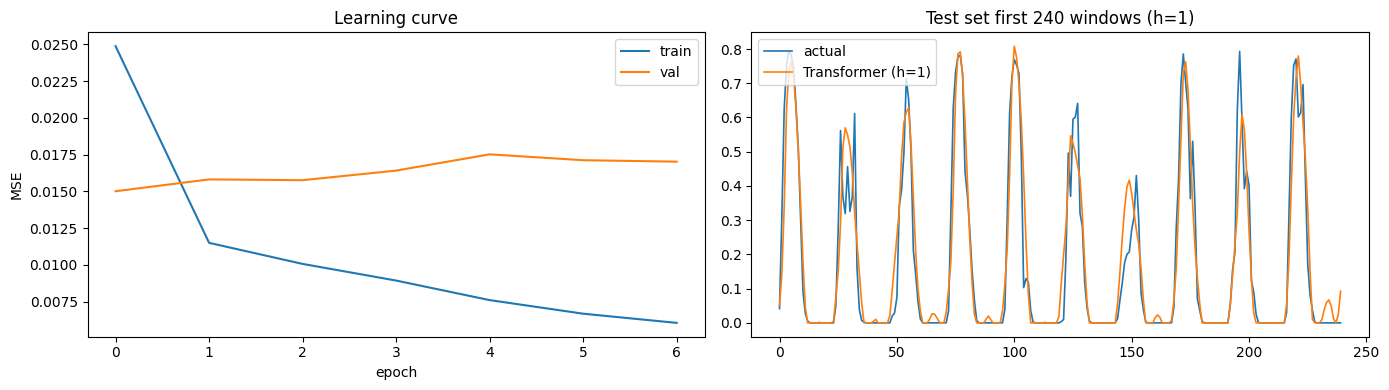

In [7]:
from src.vanilla_transformer import forecast_report, seasonal_naive

# test_dl is shuffle=False, so pred / true / naive all line up with test_ds order
pred, true = trainer.predict(test_dl, return_targets=True, clip=(0, 1))
naive = seasonal_naive(test_ds, period=H)          # same hours, previous day (H = 24)

def report(name, y, p):
    r = forecast_report(y, p)
    print(f"{name:<16} RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}")

print("test set, POWER, full 24h horizon:")
report("Transformer", true, pred)
report("Seasonal-naive", true, naive)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE"); ax[0].legend(); ax[0].set_title("Learning curve")
ax[1].plot(true[:240, 0], label="actual", lw=1.2)
ax[1].plot(pred[:240, 0], label="Transformer (h=1)", lw=1.2)
ax[1].legend(); ax[1].set_title("Test set first 240 windows (h=1)")
plt.tight_layout(); plt.show()